In [1]:
import pandas as pd

# 加载三张表
orders   = pd.read_csv('orders.csv')
items    = pd.read_csv('order_items.csv')
products = pd.read_csv('products.csv')

# 查看订单表
print("=== 订单表 ===")
print(orders.shape)       # 行数和列数
print(orders.head(3))     # 前3行
print(orders.dtypes)      # 字段类型

# 查看商品明细表
print("\n=== 订单明细表 ===")
print(items.shape)
print(items.head(3))

# 查看商品表
print("\n=== 商品表 ===")
print(products.shape)
print(products.head(3))

=== 订单表 ===
(125226, 9)
   order_id  user_id     status gender                 created_at returned_at  \
0         8        5  Cancelled      F  2022-10-20 10:03:00+00:00         NaN   
1        60       44  Cancelled      F  2023-01-20 02:12:00+00:00         NaN   
2        64       46  Cancelled      F  2021-12-06 09:11:00+00:00         NaN   

  shipped_at delivered_at  num_of_item  
0        NaN          NaN            3  
1        NaN          NaN            1  
2        NaN          NaN            1  
order_id         int64
user_id          int64
status          object
gender          object
created_at      object
returned_at     object
shipped_at      object
delivered_at    object
num_of_item      int64
dtype: object

=== 订单明细表 ===
(181759, 11)
       id  order_id  user_id  product_id  inventory_item_id     status  \
0  152013    104663    83582       14235             410368  Cancelled   
1   40993     28204    22551       14235             110590   Complete   
2   51224     35

In [2]:
print("=== 缺失值统计 ===")
print("orders 缺失值：\n", orders.isnull().sum())
print("\nitems 缺失值：\n", items.isnull().sum())
print("\nproducts 缺失值：\n", products.isnull().sum())

=== 缺失值统计 ===
orders 缺失值：
 order_id             0
user_id              0
status               0
gender               0
created_at           0
returned_at     112696
shipped_at       43765
delivered_at     81342
num_of_item          0
dtype: int64

items 缺失值：
 id                        0
order_id                  0
user_id                   0
product_id                0
inventory_item_id         0
status                    0
created_at                0
shipped_at            63478
delivered_at         117918
returned_at          163527
sale_price                0
dtype: int64

products 缺失值：
 id                         0
cost                       0
category                   0
name                       2
brand                     24
retail_price               0
department                 0
sku                        0
distribution_center_id     0
dtype: int64


In [3]:
# ===== 1. 日期字段转换 =====
date_cols_orders = ['created_at', 'returned_at', 'shipped_at', 'delivered_at']
date_cols_items  = ['created_at', 'shipped_at', 'delivered_at', 'returned_at']

for col in date_cols_orders:
    orders[col] = pd.to_datetime(orders[col], utc=True, errors='coerce')

for col in date_cols_items:
    items[col] = pd.to_datetime(items[col], utc=True, errors='coerce')

print("日期转换完成")
print(orders[['created_at','shipped_at']].dtypes)

日期转换完成
created_at    datetime64[ns, UTC]
shipped_at    datetime64[ns, UTC]
dtype: object


In [4]:
# ===== 2. 处理 products 缺失值 =====
# name 只缺 2 条，直接删掉
products = products.dropna(subset=['name'])

# brand 缺 24 条，填充为 'Unknown'
products['brand'] = products['brand'].fillna('Unknown')

print("products 缺失值处理后：")
print(products.isnull().sum())

products 缺失值处理后：
id                        0
cost                      0
category                  0
name                      0
brand                     0
retail_price              0
department                0
sku                       0
distribution_center_id    0
dtype: int64


In [5]:
# ===== 3. 检查 sale_price 异常值 =====
print("sale_price 统计：")
print(items['sale_price'].describe())

# 看看价格分布
print("\n价格低于 1 元的订单数量：", (items['sale_price'] < 1).sum())
print("价格为 0 的订单数量：", (items['sale_price'] == 0).sum())

sale_price 统计：
count    181759.000000
mean         59.568544
std          66.657262
min           0.020000
25%          24.500000
50%          39.990002
75%          69.949997
max         999.000000
Name: sale_price, dtype: float64

价格低于 1 元的订单数量： 10
价格为 0 的订单数量： 0


In [6]:
# ===== 4. 新增衍生字段 =====
# 订单年月（用于后续趋势分析）
import warnings
warnings.filterwarnings('ignore')
orders['year']  = orders['created_at'].dt.year
orders['month'] = orders['created_at'].dt.month
orders['year_month'] = orders['created_at'].dt.to_period('M')

# 订单状态简化确认
print("订单状态分布：")
print(orders['status'].value_counts())

订单状态分布：
status
Shipped       37577
Complete      31354
Processing    25156
Cancelled     18609
Returned      12530
Name: count, dtype: int64


In [7]:
# ===== 5. 保存清洗后的数据 =====
orders.to_csv('orders_clean.csv', index=False)
items.to_csv('items_clean.csv', index=False)
products.to_csv('products_clean.csv', index=False)

print("✓ 三张清洗后的表已保存")

✓ 三张清洗后的表已保存


In [8]:
# ===== 1. 删除异常低价（< 1 美元）=====
print("删除前 items 行数：", len(items))
items = items[items['sale_price'] >= 1]
print("删除后 items 行数：", len(items))

删除前 items 行数： 181759
删除后 items 行数： 181749


In [9]:
# ===== 2. 合并表，加入品类信息 =====
# items 合并 products，加入 category / department / brand
items_merged = items.merge(
    products[['id', 'category', 'department', 'brand', 'cost', 'retail_price']],
    left_on='product_id',
    right_on='id',
    how='left'
)

# items 合并 orders，加入年月信息
items_merged = items_merged.merge(
    orders[['order_id', 'year', 'month', 'year_month', 'status']],
    on='order_id',
    how='left'
)

print("合并后字段：")
print(items_merged.columns.tolist())
print("\n合并后行数：", len(items_merged))


合并后字段：
['id_x', 'order_id', 'user_id', 'product_id', 'inventory_item_id', 'status_x', 'created_at', 'shipped_at', 'delivered_at', 'returned_at', 'sale_price', 'id_y', 'category', 'department', 'brand', 'cost', 'retail_price', 'year', 'month', 'year_month', 'status_y']

合并后行数： 181749


In [10]:
# ===== 3. 新增利润字段 =====
# 毛利润 = 售价 - 成本
items_merged['profit'] = items_merged['sale_price'] - items_merged['cost']

# 毛利率 = 毛利润 / 售价
items_merged['profit_margin'] = items_merged['profit'] / items_merged['sale_price']

print("利润字段统计：")
print(items_merged[['sale_price', 'cost', 'profit', 'profit_margin']].describe().round(2))

利润字段统计：
       sale_price       cost     profit  profit_margin
count   181749.00  181739.00  181739.00      181739.00
mean        59.57      28.66      30.91           0.51
std         66.66      31.02      36.62           0.07
min          1.50       0.61       0.74           0.33
25%         24.50      11.37      11.73           0.45
50%         39.99      19.83      20.12           0.51
75%         69.95      34.55      35.88           0.57
max        999.00     557.15     594.40           0.67


In [11]:
# ===== 4. 保存最终分析表 =====
items_merged.to_csv('items_final.csv', index=False)
print("✓ items_final.csv 已保存，D3 完成！")
print(f"最终分析表：{len(items_merged)} 行，{len(items_merged.columns)} 列")

✓ items_final.csv 已保存，D3 完成！
最终分析表：181749 行，23 列


In [12]:
import sqlite3

# 把 Period 类型转成字符串
items_merged['year_month'] = items_merged['year_month'].astype(str)
orders['year_month'] = orders['year_month'].astype(str)

# 建立数据库连接
conn = sqlite3.connect('thelook.db')

# 导入三张表
items_merged.to_sql('items', conn, if_exists='replace', index=False)
orders.to_sql('orders', conn, if_exists='replace', index=False)
products.to_sql('products', conn, if_exists='replace', index=False)

print("✓ 数据已导入 SQLite")

✓ 数据已导入 SQLite


In [13]:
# ===== 查询1：各品类销售额排名 =====
q1 = """
SELECT 
    category,
    COUNT(*) AS 订单数,
    ROUND(SUM(sale_price), 0) AS 总销售额,
    ROUND(AVG(sale_price), 2) AS 平均售价
FROM items
WHERE status_y = 'Complete'
GROUP BY category
ORDER BY 总销售额 DESC
LIMIT 10
"""
df_q1 = pd.read_sql(q1, conn)
print("=== 各品类销售额排名 ===")
print(df_q1.to_string(index=False))

=== 各品类销售额排名 ===
                     category  订单数     总销售额   平均售价
            Outerwear & Coats 2299 329564.0 143.35
                        Jeans 3143 314433.0 100.04
                     Sweaters 2809 216190.0  76.96
          Suits & Sport Coats 1237 163445.0 132.13
                         Swim 2860 161576.0  56.50
Fashion Hoodies & Sweatshirts 2929 159890.0  54.59
               Sleep & Lounge 2841 137708.0  48.47
                       Shorts 2756 124042.0  45.01
                  Tops & Tees 2974 122837.0  41.30
                       Active 2323 122689.0  52.81


In [14]:
# ===== 查询2：订单状态分布 + 取消率 =====
q2 = """
SELECT
    status_y AS 订单状态,
    COUNT(*) AS 数量,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 1) AS 占比
FROM items
GROUP BY status_y
ORDER BY 数量 DESC
"""
df_q2 = pd.read_sql(q2, conn)
print("\n=== 订单状态分布 ===")
print(df_q2.to_string(index=False))


=== 订单状态分布 ===
      订单状态    数量   占比
   Shipped 54435 30.0
  Complete 45605 25.1
Processing 36388 20.0
 Cancelled 27089 14.9
  Returned 18232 10.0


In [15]:
# ===== 查询3：男女部门销售额对比 =====
q3 = """
SELECT
    department AS 部门,
    ROUND(SUM(sale_price), 0) AS 总销售额,
    ROUND(AVG(profit_margin) * 100, 1) AS 平均毛利率
FROM items
WHERE status_y = 'Complete'
GROUP BY department
ORDER BY 总销售额 DESC
"""
df_q3 = pd.read_sql(q3, conn)
print("\n=== 男女部门销售对比 ===")
print(df_q3.to_string(index=False))


=== 男女部门销售对比 ===
   部门      总销售额  平均毛利率
  Men 1449386.0   50.8
Women 1266325.0   51.4
 None      72.0    NaN


In [16]:
# ===== 查询4：月度销售趋势 =====
q4 = """
SELECT
    year_month AS 年月,
    COUNT(*) AS 订单数,
    ROUND(SUM(sale_price), 0) AS 月销售额
FROM items
WHERE status_y = 'Complete'
  AND year_month >= '2022-01'
GROUP BY year_month
ORDER BY year_month
"""
df_q4 = pd.read_sql(q4, conn)
print("=== 月度销售趋势 ===")
print(df_q4.to_string(index=False))

=== 月度销售趋势 ===
     年月  订单数     月销售额
2022-01  717  40740.0
2022-02  614  34454.0
2022-03  739  41574.0
2022-04  753  43267.0
2022-05  861  53119.0
2022-06  830  53467.0
2022-07  888  53158.0
2022-08 1004  54542.0
2022-09  851  51506.0
2022-10 1141  72303.0
2022-11 1113  66346.0
2022-12 1128  65869.0
2023-01 1240  73593.0
2023-02 1226  73520.0
2023-03 1333  79785.0
2023-04 1304  76381.0
2023-05 1537  91229.0
2023-06 1594  94940.0
2023-07 1806 109932.0
2023-08 1780 110789.0
2023-09 1944 116710.0
2023-10 2203 132170.0
2023-11 2532 147397.0
2023-12 3024 179675.0
2024-01 2176 130641.0
    NaT 1107  66490.0


In [17]:
# ===== 查询5：各品类取消率排名 =====
q5 = """
SELECT
    category AS 品类,
    COUNT(*) AS 总订单数,
    SUM(CASE WHEN status_y = 'Cancelled' THEN 1 ELSE 0 END) AS 取消数,
    ROUND(SUM(CASE WHEN status_y = 'Cancelled' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS 取消率
FROM items
GROUP BY category
ORDER BY 取消率 DESC
LIMIT 10
"""
df_q5 = pd.read_sql(q5, conn)
print("\n=== 各品类取消率排名 ===")
print(df_q5.to_string(index=False))


=== 各品类取消率排名 ===
               品类  总订单数  取消数  取消率
             None    10    5 50.0
    Clothing Sets   213   34 16.0
      Accessories  9743 1530 15.7
  Socks & Hosiery  3787  578 15.3
            Jeans 12698 1943 15.3
            Socks  6346  965 15.2
Blazers & Jackets  3205  488 15.2
             Swim 11428 1731 15.1
            Suits  1024  155 15.1
   Pants & Capris  3389  511 15.1


In [18]:
# ===== 查询6：高销售额品牌 TOP10 =====
q6 = """
SELECT
    brand AS 品牌,
    COUNT(*) AS 订单数,
    ROUND(SUM(sale_price), 0) AS 总销售额,
    ROUND(AVG(profit_margin) * 100, 1) AS 平均毛利率
FROM items
WHERE status_y = 'Complete'
  AND brand != 'Unknown'
GROUP BY brand
ORDER BY 总销售额 DESC
LIMIT 10
"""
df_q6 = pd.read_sql(q6, conn)
print("\n=== 品牌销售额 TOP10 ===")
print(df_q6.to_string(index=False))


=== 品牌销售额 TOP10 ===
               品牌  订单数    总销售额  平均毛利率
           Diesel  395 54921.0   50.4
     Calvin Klein  791 49152.0   51.7
7 For All Mankind  299 48633.0   47.9
    True Religion  245 47706.0   48.0
         Carhartt  612 42620.0   52.4
   Tommy Hilfiger  424 31860.0   51.9
   The North Face   61 27415.0   54.7
         Columbia  379 27366.0   54.6
           Volcom  469 26676.0   48.2
      Joe's Jeans  172 26466.0   47.1


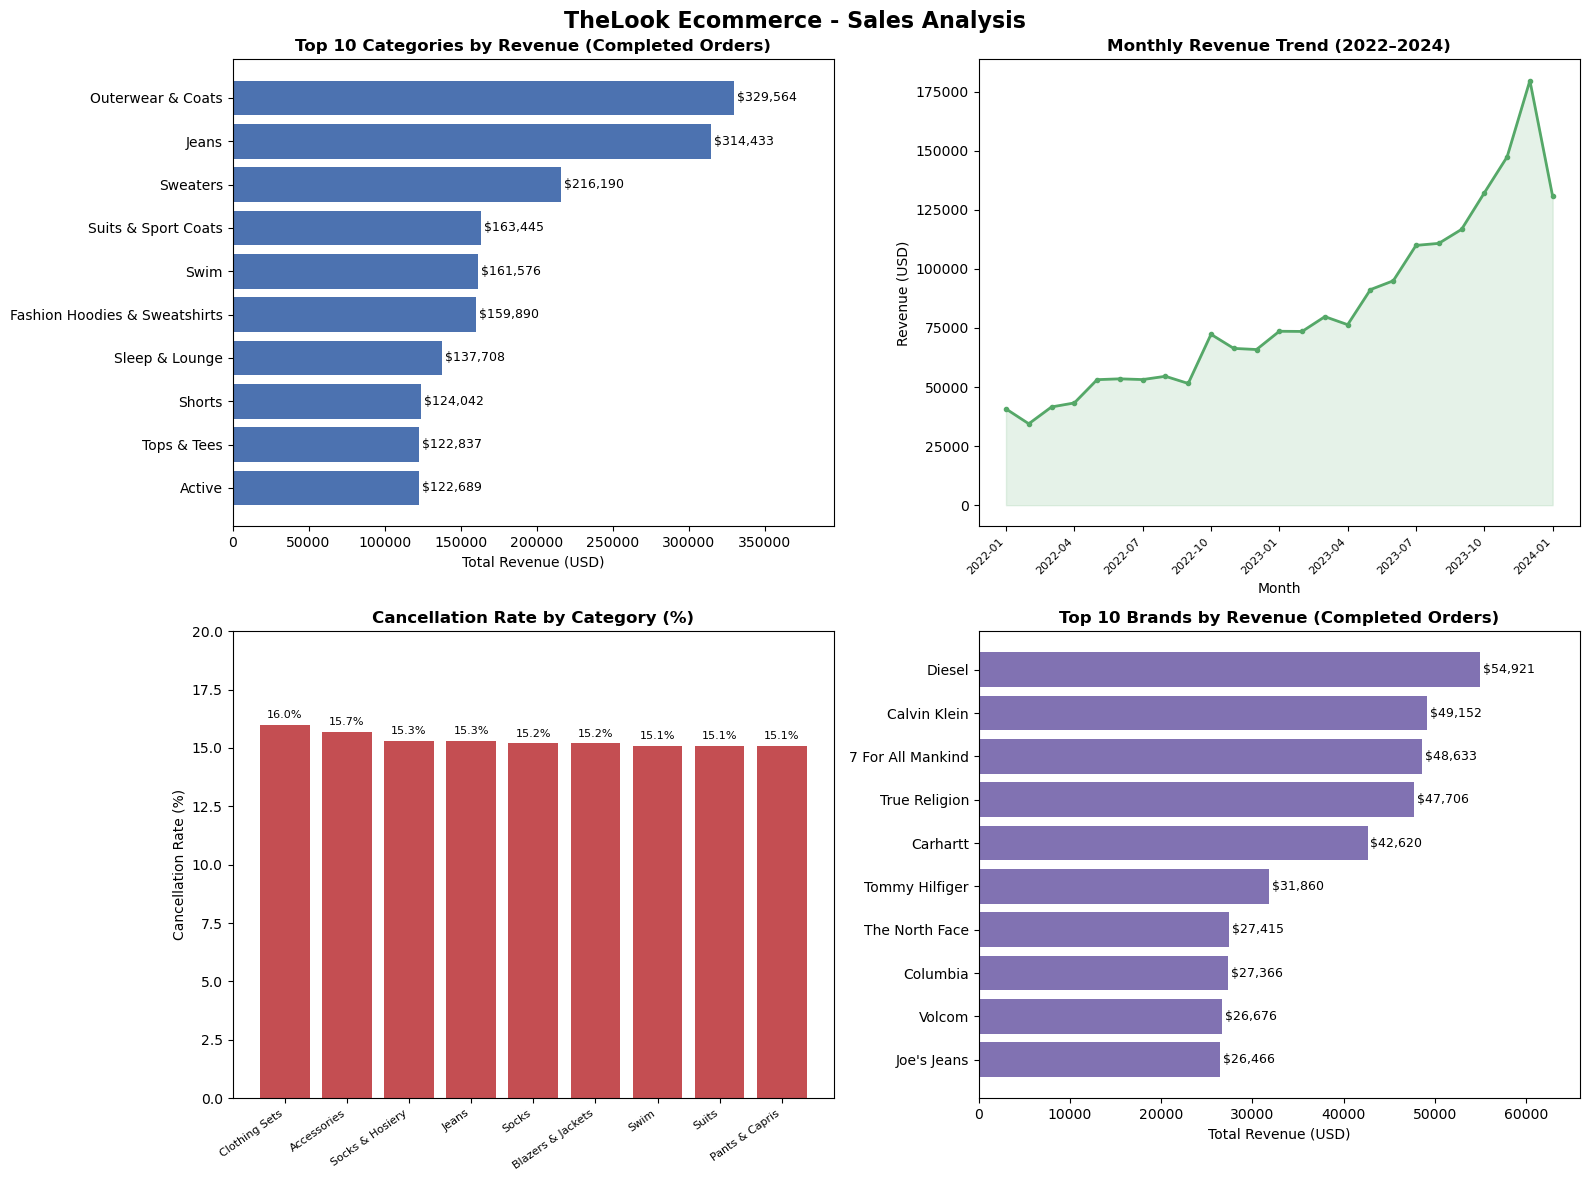

✓ 图表已保存为 sales_analysis.png


In [19]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('TheLook Ecommerce - Sales Analysis', fontsize=16, fontweight='bold', y=0.98)

# ===== 图1：品类销售额排名 =====
ax1 = axes[0, 0]
ax1.barh(df_q1['category'][::-1], df_q1['总销售额'][::-1], color='#4C72B0')
ax1.set_title('Top 10 Categories by Revenue (Completed Orders)', fontweight='bold')
ax1.set_xlabel('Total Revenue (USD)')
for i, v in enumerate(df_q1['总销售额'][::-1]):
    ax1.text(v + 2000, i, f'${v:,.0f}', va='center', fontsize=9)
ax1.set_xlim(0, df_q1['总销售额'].max() * 1.2)

# ===== 图2：月度销售趋势 =====
ax2 = axes[0, 1]
df_trend = df_q4[df_q4['年月'] != 'NaT'].copy()
x = range(len(df_trend))
ax2.plot(x, df_trend['月销售额'], color='#55A868', linewidth=2, marker='o', markersize=3)
ax2.fill_between(x, df_trend['月销售额'], alpha=0.15, color='#55A868')
ax2.set_title('Monthly Revenue Trend (2022–2024)', fontweight='bold')
ax2.set_xlabel('Month')
ax2.set_ylabel('Revenue (USD)')
tick_step = 3
ax2.set_xticks(list(x)[::tick_step])
ax2.set_xticklabels(df_trend['年月'].tolist()[::tick_step], rotation=45, ha='right', fontsize=8)

# ===== 图3：品类取消率 =====
ax3 = axes[1, 0]
df_cancel = df_q5[df_q5['品类'].notna() & (df_q5['品类'] != 'None')]
bars = ax3.bar(df_cancel['品类'], df_cancel['取消率'], color='#C44E52')
ax3.set_title('Cancellation Rate by Category (%)', fontweight='bold')
ax3.set_ylabel('Cancellation Rate (%)')
ax3.set_ylim(0, 20)
plt.setp(ax3.get_xticklabels(), rotation=35, ha='right', fontsize=8)
for bar, val in zip(bars, df_cancel['取消率']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val}%', ha='center', va='bottom', fontsize=8)

# ===== 图4：品牌 TOP10 =====
ax4 = axes[1, 1]
ax4.barh(df_q6['品牌'][::-1], df_q6['总销售额'][::-1], color='#8172B2')
ax4.set_title('Top 10 Brands by Revenue (Completed Orders)', fontweight='bold')
ax4.set_xlabel('Total Revenue (USD)')
for i, v in enumerate(df_q6['总销售额'][::-1]):
    ax4.text(v + 300, i, f'${v:,.0f}', va='center', fontsize=9)
ax4.set_xlim(0, df_q6['总销售额'].max() * 1.2)

plt.tight_layout()
plt.savefig('sales_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ 图表已保存为 sales_analysis.png")

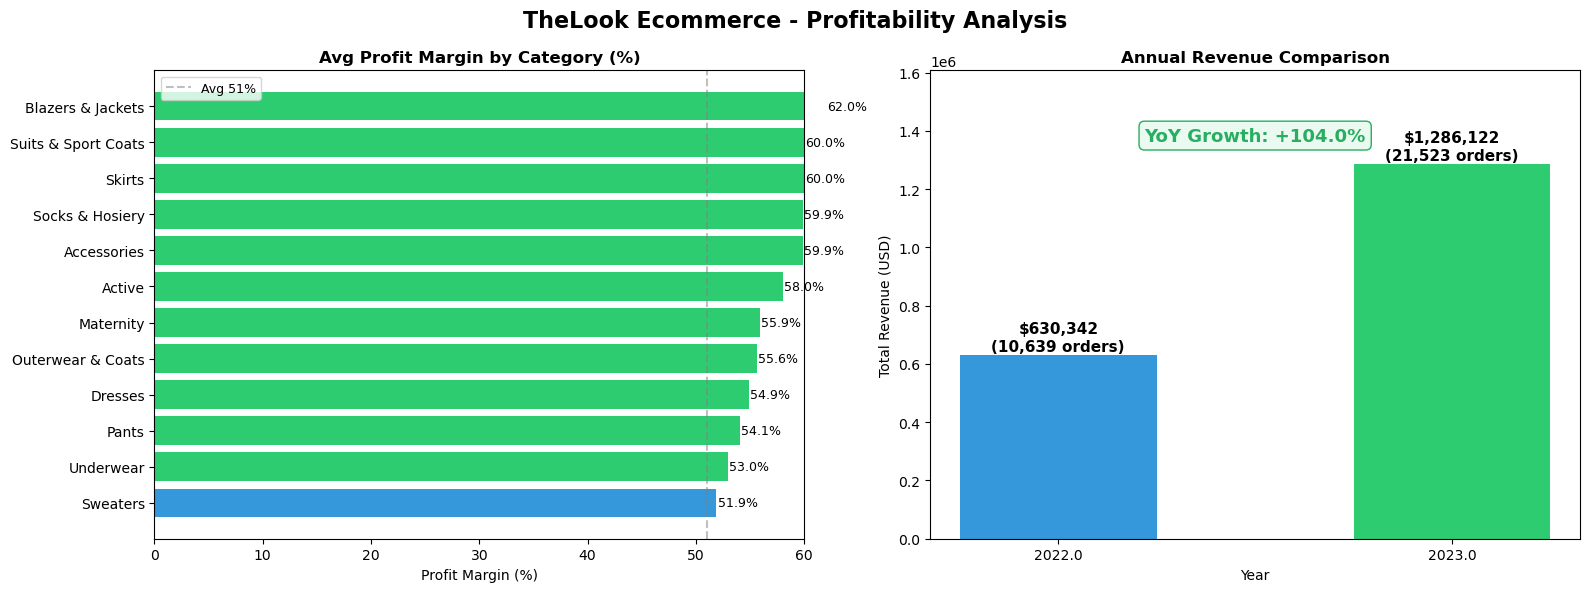

✓ 图表已保存为 profitability_analysis.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('TheLook Ecommerce - Profitability Analysis', fontsize=16, fontweight='bold')

# ===== 图5：各品类平均毛利率 =====
q7 = """
SELECT category AS 品类,
       ROUND(AVG(profit_margin) * 100, 1) AS 平均毛利率,
       ROUND(SUM(sale_price), 0) AS 总销售额
FROM items
WHERE status_y = 'Complete' AND profit_margin IS NOT NULL
GROUP BY category
ORDER BY 平均毛利率 DESC
LIMIT 12
"""
df_q7 = pd.read_sql(q7, conn)

ax1 = axes[0]
colors = ['#2ecc71' if x >= 52 else '#3498db' if x >= 50 else '#e74c3c'
          for x in df_q7['平均毛利率']]
bars = ax1.barh(df_q7['品类'][::-1], df_q7['平均毛利率'][::-1], color=colors[::-1])
ax1.set_title('Avg Profit Margin by Category (%)', fontweight='bold')
ax1.set_xlabel('Profit Margin (%)')
ax1.axvline(x=51, color='gray', linestyle='--', alpha=0.5, label='Avg 51%')
ax1.legend(fontsize=9)
for i, v in enumerate(df_q7['平均毛利率'][::-1]):
    ax1.text(v + 0.1, i, f'{v}%', va='center', fontsize=9)
ax1.set_xlim(0, 60)

# ===== 图6：年度销售额对比 =====
q8 = """
SELECT year AS 年份,
       COUNT(*) AS 订单数,
       ROUND(SUM(sale_price), 0) AS 年销售额
FROM items
WHERE status_y = 'Complete' AND year IN (2022, 2023)
GROUP BY year
ORDER BY year
"""
df_q8 = pd.read_sql(q8, conn)

ax2 = axes[1]
bars2 = ax2.bar(df_q8['年份'].astype(str), df_q8['年销售额'],
                color=['#3498db', '#2ecc71'], width=0.5)
ax2.set_title('Annual Revenue Comparison', fontweight='bold')
ax2.set_ylabel('Total Revenue (USD)')
ax2.set_xlabel('Year')
for bar, val, orders in zip(bars2, df_q8['年销售额'], df_q8['订单数']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
             f'${val:,.0f}\n({orders:,} orders)',
             ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.set_ylim(0, df_q8['年销售额'].max() * 1.25)

growth = (df_q8['年销售额'].iloc[1] - df_q8['年销售额'].iloc[0]) / df_q8['年销售额'].iloc[0] * 100
ax2.text(0.5, 0.85, f'YoY Growth: +{growth:.1f}%',
         transform=ax2.transAxes, ha='center', fontsize=13,
         color='#27ae60', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='#eafaf1', edgecolor='#27ae60'))

plt.tight_layout()
plt.savefig('profitability_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ 图表已保存为 profitability_analysis.png")

In [21]:
# 这个 cell 是纯 Markdown 报告，直接在 Jupyter 里改 cell 类型为 Markdown 后粘贴
# 或者用下面代码生成报告文字，复制到新 Markdown cell
report = """
# TheLook Ecommerce 销售数据分析报告

## 一、背景
本报告基于 TheLook Ecommerce 平台 2019–2024 年真实交易数据，
重点分析 2022–2023 年销售表现，涵盖品类、品牌、毛利率及订单健康度四个维度，
旨在识别高价值品类与潜在业务风险，为运营决策提供数据支撑。

## 二、数据说明
- 数据来源：TheLook Ecommerce（Google BigQuery 公开数据集）
- 分析区间：2022年1月 – 2023年12月
- 数据规模：181,749 条订单明细，涵盖订单、商品、品牌、状态等 23 个字段
- 数据处理：删除售价异常记录（< $1）共 10 条；补全品牌缺失值 24 条；
            日期字段统一转换为 datetime 格式；新增毛利润、毛利率衍生字段

## 三、核心发现

### 发现1：年销售额实现翻倍增长，增速达 104%
2022 年完成订单销售额为 $630,342（10,639 单），
2023 年增长至 $1,286,122（21,523 单），同比增长 **104%**。
其中 2023 年下半年增速明显加快，12 月单月销售额达到 $179,675，
为全年最高点，显示出强烈的季节性购买高峰。

### 发现2：外套品类销售额领先，但西装外套毛利率最高
从销售额看，Outerwear & Coats 以 $329,564 位居第一，Jeans 以 $314,433 紧随其后；
从毛利率看，Blazers & Jackets 以 **62%** 的毛利率居首，
比平均毛利率（51%）高出 11 个百分点。
两项指标的背离说明：销量大的品类不一定利润最优，
建议在旺季加大对 Blazers & Jackets 的资源投入以提升整体利润。

### 发现3：约 25% 的订单未能成功完成，存在明显收入损耗
全部订单中取消率为 **14.9%**，退货率为 **10.0%**，
合计约 **24.9%** 的订单未能完成交易。
各品类取消率集中在 15–16%，分布均匀，说明这是平台层面的系统性问题，
而非个别品类问题。若将取消 + 退货率降低 5 个百分点，
按现有规模估算可额外挽回约 $160,000 年销售额。

## 四、业务建议

### 建议1：在 Q4 旺季前重点备货高毛利品类
数据显示 2023 年 10–12 月销售额环比大幅增长，
建议在 9 月前完成 Blazers & Jackets、Suits & Sport Coats 等
高毛利品类的库存备货，并配合营销活动提前预热，
以最大化利用季节性峰值。

### 建议2：建立取消 & 退货预警机制，重点排查高频取消品类
建议对取消率超过 16% 的品类（如 Clothing Sets、Accessories）
进行专项分析，排查是否存在商品描述不准确、尺码信息缺失、
配送时效过长等问题，从根源降低取消和退货率，
提升订单完成率和用户体验。

## 五、分析工具
- Python（Pandas）：数据清洗、字段处理、表合并
- SQLite + SQL：多维度聚合查询与业务指标计算  
- Matplotlib / Seaborn：数据可视化，共生成 6 张图表
- GitHub：项目代码与数据已开源
"""

print(report)


# TheLook Ecommerce 销售数据分析报告

## 一、背景
本报告基于 TheLook Ecommerce 平台 2019–2024 年真实交易数据，
重点分析 2022–2023 年销售表现，涵盖品类、品牌、毛利率及订单健康度四个维度，
旨在识别高价值品类与潜在业务风险，为运营决策提供数据支撑。

## 二、数据说明
- 数据来源：TheLook Ecommerce（Google BigQuery 公开数据集）
- 分析区间：2022年1月 – 2023年12月
- 数据规模：181,749 条订单明细，涵盖订单、商品、品牌、状态等 23 个字段
- 数据处理：删除售价异常记录（< $1）共 10 条；补全品牌缺失值 24 条；
            日期字段统一转换为 datetime 格式；新增毛利润、毛利率衍生字段

## 三、核心发现

### 发现1：年销售额实现翻倍增长，增速达 104%
2022 年完成订单销售额为 $630,342（10,639 单），
2023 年增长至 $1,286,122（21,523 单），同比增长 **104%**。
其中 2023 年下半年增速明显加快，12 月单月销售额达到 $179,675，
为全年最高点，显示出强烈的季节性购买高峰。

### 发现2：外套品类销售额领先，但西装外套毛利率最高
从销售额看，Outerwear & Coats 以 $329,564 位居第一，Jeans 以 $314,433 紧随其后；
从毛利率看，Blazers & Jackets 以 **62%** 的毛利率居首，
比平均毛利率（51%）高出 11 个百分点。
两项指标的背离说明：销量大的品类不一定利润最优，
建议在旺季加大对 Blazers & Jackets 的资源投入以提升整体利润。

### 发现3：约 25% 的订单未能成功完成，存在明显收入损耗
全部订单中取消率为 **14.9%**，退货率为 **10.0%**，
合计约 **24.9%** 的订单未能完成交易。
各品类取消率集中在 15–16%，分布均匀，说明这是平台层面的系统性问题，
而非个别品类问题。若将取消 + 退货率降低 5 个百分点，
按现有规模估算可额外挽回约 $160,000 年销售额。

## 四、业务建议

### 建议1：在 Q